# Multi Head Attention

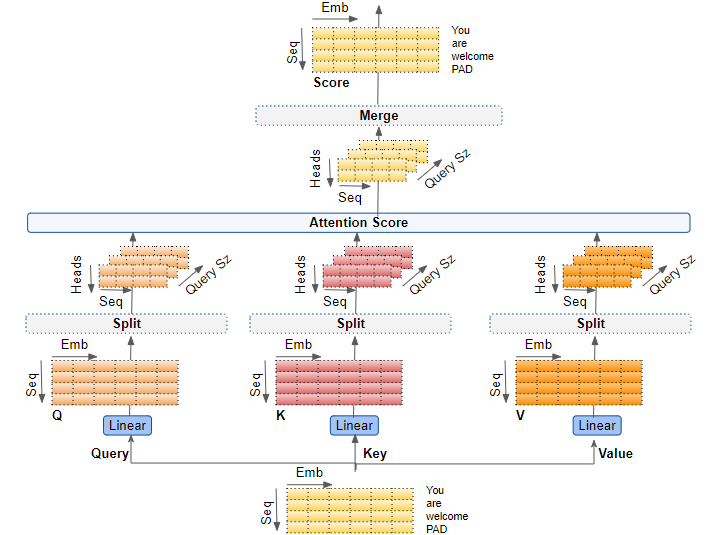

## What it does
Takes an input sequence `(b, T, d_in)` and returns a **context-aware** output of the same shape, where each token vector has been updated by attending to all previous tokens (causal).

---

## Core idea
- Project input into **Q, K, V** with three separate linear layers.
- Split the `d_out` dimension across `H` heads → each head works in a `head_dim = d_out / H` subspace.
- Run scaled dot-product attention **independently per head**.
- Concatenate heads, then mix with a final `out_proj` linear layer.

---

## Step-by-step forward pass

| Step | Operation | Shape change |
|------|-----------|-------------|
| 1 | `W_q/k/v` projections | `(b,T,d_in)` → `(b,T,d_out)` |
| 2 | `.view()` + `.transpose()` | `(b,T,d_out)` → `(b,H,T,h)` |
| 3 | `Q @ Kᵀ` — attention scores | `(b,H,T,T)` |
| 4 | Divide by `√head_dim` | scale (same shape) |
| 5 | Causal mask → fill upper triangle with `−∞` | (same shape) |
| 6 | `softmax(dim=-1)` + dropout | `(b,H,T,T)` |
| 7 | `weights @ V` → `.transpose()` | `(b,T,H,h)` |
| 8 | `.contiguous().view()` — concat heads | `(b,T,d_out)` |
| 9 | `out_proj` — mix across heads | `(b,T,d_out)` |

---

## Key design choices

**Why split into heads?**  
Each head learns to attend to different things (syntax, semantics, position, etc.). `out_proj` then blends their outputs.

**Why scale by `1/√head_dim`?**  
Large dot-products → peaky softmax → near-zero gradients on non-attended tokens. Scaling keeps the softmax distribution smooth during training.

**Causal mask (`torch.triu(..., diagonal=1)`)**  
Upper-triangle positions = future tokens → set to `−∞` before softmax → `exp(−∞) = 0`. Registered as a buffer (not a parameter; moves to GPU but no grad).

**Why `.contiguous()` before `.view()`?**  
`.transpose()` doesn't rearrange memory, just metadata. `.view()` requires contiguous memory, so `.contiguous()` forces an actual copy first.

**`out_proj` purpose**  
Without it, each head's output sits in its own `d_out/H` slice — no information mixes across heads. The projection lets the model learn cross-head combinations.

In [ ]:
import torch
import torch.nn as nn

# ============================================================
# MULTI-HEAD ATTENTION
# ============================================================
# VISUAL REFERENCE (diagram 1 — tensor shape flow):
#
#   Input (b,T,d_in)
#     → W_q / W_k / W_v projections → Q, K, V  shape: (b, T, d_out)
#     → .view()  split d_out into H heads       shape: (b, T, H, h)
#     → .transpose(1,2)  heads move forward     shape: (b, H, T, h)
#     → Q @ Kᵀ  one T×T score matrix per head   shape: (b, H, T, T)
#     → causal mask + softmax → weights         shape: (b, H, T, T)
#     → weights @ V                             shape: (b, H, T, h)
#     → .transpose(1,2) + .view()  concat heads shape: (b, T, d_out)
#     → out_proj                                shape: (b, T, d_out)  ← same as input
#
# WHY MULTIPLE HEADS?
#   Each head projects into a different d_out/H subspace.
#   One head might learn syntax, another semantics, another
#   positional proximity.  The final out_proj mixes them.
# ============================================================

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # h in diagrams — each head sees this many dims

        # --- Three parallel projections: same input, different learned weight matrices ---
        # These are NOT shared. Each head slice gets its own effective weights because
        # we split the d_out dimension H ways after the projection.
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)  # (d_in → d_out)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # --- Output projection: mixes all H heads back together ---
        # Learned blend — the model decides how much of each head's output to use.
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)

        # --- Causal mask (diagram 3) ---
        # torch.triu(..., diagonal=1) sets the upper triangle (future positions) to 1.
        # register_buffer: saved with model weights, moves to GPU automatically,
        # but NOT a parameter — gradients never flow through it.
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
            # diagonal=1 means position (i,i) stays 0 — each token CAN attend to itself
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape   # unpack: batch, sequence length, embedding dim

        # ── STEP 1: Project to Q, K, V ─────────────────────────────────────────────
        # All three have the same shape: (b, T, d_out)
        # Think of this as the token saying "this is my question (Q), my label (K),
        # and my content (V)."
        queries = self.W_query(x)   # (b, T, d_out)
        keys    = self.W_key(x)     # (b, T, d_out)
        values  = self.W_value(x)   # (b, T, d_out)

        # ── STEP 2: Reshape to split into heads ────────────────────────────────────
        # .view() reinterprets d_out as (num_heads, head_dim) — no data movement.
        # .transpose(1,2) brings heads forward so PyTorch's batched matmul treats
        # each head independently (the batch dimension becomes b*H effectively).
        #
        # (b, T, d_out)  →  (b, T, H, h)  →  (b, H, T, h)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys   .view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values .view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # ── STEP 3: Scaled dot-product attention scores ────────────────────────────
        # Q @ Kᵀ   →   (b, H, T, h) @ (b, H, h, T)  =  (b, H, T, T)
        # Each [i,j] entry = how much query-token i attends to key-token j.
        # keys.transpose(2, 3) flips only the last two dims: (b,H,T,h) → (b,H,h,T)
        attn_scores = queries @ keys.transpose(2, 3)   # (b, H, T, T)

        # Scale by 1/√head_dim to keep dot-products from getting huge.
        # Large values → peaky softmax → near-zero gradients on non-attended tokens.
        attn_scores = attn_scores / (self.head_dim ** 0.5)

        # ── STEP 4: Apply causal mask (diagram 3) ──────────────────────────────────
        # Slice the pre-built mask to the actual sequence length (could be < context_length).
        # Wherever mask == True (upper triangle = future tokens), write −∞.
        # After softmax, exp(−∞) → 0 so those positions contribute nothing.
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]   # (T, T) boolean
        attn_scores.masked_fill_(mask_bool, -torch.inf)           # in-place fill

        # ── STEP 5: Softmax + dropout ───────────────────────────────────────────────
        # dim=-1 → softmax over the KEY dimension: each query row sums to 1.
        # Dropout randomly zeros some weights during training to prevent over-reliance
        # on specific token pairs.
        attn_weights = torch.softmax(attn_scores, dim=-1)   # (b, H, T, T)
        attn_weights = self.dropout(attn_weights)

        # ── STEP 6: Weighted sum of Values ─────────────────────────────────────────
        # (b, H, T, T) @ (b, H, T, h)  =  (b, H, T, h)
        # Each output token = a blend of all value vectors, weighted by attention.
        # Then .transpose(1,2) puts token-dim back before head-dim: (b, T, H, h)
        context_vec = (attn_weights @ values).transpose(1, 2)   # (b, T, H, h)

        # ── STEP 7: Concatenate all heads ──────────────────────────────────────────
        # .contiguous() ensures the tensor is laid out contiguously in memory
        # (needed after transpose before .view() can reshape across those dims).
        # .view() merges (H, h) back into d_out.  H * h == d_out by construction.
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)  # (b, T, d_out)

        # ── STEP 8: Output projection ──────────────────────────────────────────────
        # A final learned linear layer to mix information *across* heads.
        # Without this, each head's output sits in its own slice — no cross-head mixing.
        context_vec = self.out_proj(context_vec)   # (b, T, d_out)

        return context_vec   # same shape as input x, but now every vector is context-aware


# ── Quick sanity test ──────────────────────────────────────────────────────────
torch.manual_seed(123)
batch_size, context_length, d_in = 2, 4, 256
d_out      = 256
num_heads  = 8   # head_dim = 256/8 = 32

mock_inputs = torch.randn(batch_size, context_length, d_in)
mha = MultiHeadAttention(d_in, d_out, context_length, dropout=0.0, num_heads=num_heads)
output = mha(mock_inputs)

print("Input  (b, T, d_in) :", mock_inputs.shape)   # torch.Size([2, 4, 256])
print("Output (b, T, d_out):", output.shape)          # torch.Size([2, 4, 256])
# Shape is preserved — but each vector now encodes context from every earlier token.

Input  (b, T, d_in) : torch.Size([2, 4, 256])
Output (b, T, d_out): torch.Size([2, 4, 256])


# RoPE Integration

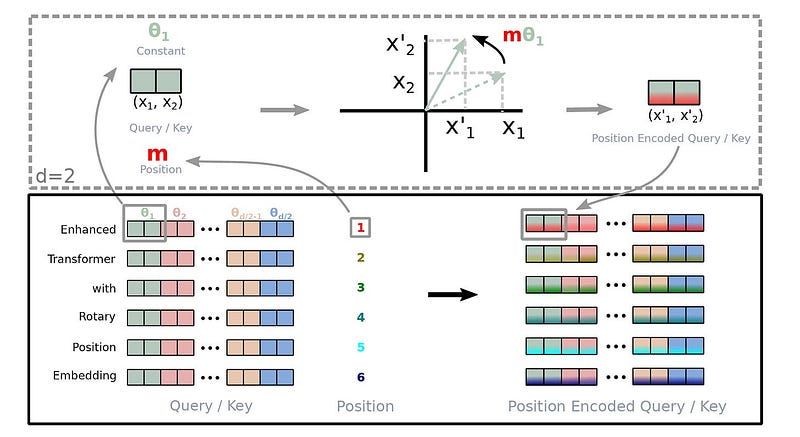

## Core Idea
Instead of *adding* positional info to embeddings, RoPE **rotates** each pair of dimensions `(x₁, x₂)` by an angle proportional to the token position `m`:

```
x_out = x·cos(m·θᵢ) + [−x₂, x₁]·sin(m·θᵢ)
```

**Key property:** The `Q·Kᵀ` dot product after rotation only depends on `(m−n)·θᵢ` — the model sees **relative distances** for free, without ever being told position directly.

---

## Frequency Schedule
```
θᵢ = 1 / (base ^ (2i / head_dim))
```
- **Small i → high freq → fast rotation** → encodes fine-grained local positions  
- **Large i → low freq → slow rotation** → encodes long-range structure  

Same idea as sinusoidal embeddings, but applied as a rotation instead of an addition.

---

## 3 Components

### 1. `precompute_rope_params` — runs once at init
Builds a `(context_length, head_dim)` table of `cos` and `sin` values.
- Computes `θᵢ` for each dimension pair → shape `(head_dim/2,)`
- Outer-products with positions `0…T-1` → angles shape `(ctx, head_dim/2)`
- Concatenates angles twice → `(ctx, head_dim)` so both halves of the head are covered
- Stored as a **buffer** (device-synced, not trained)

### 2. `compute_rope` — applied to Q and K each forward pass

| Step | Operation |
|------|-----------|
| A | Split `x` into `x1` (first half) and `x2` (second half) along `head_dim` |
| B | Trim `cos/sin` to current `seq_len`, unsqueeze for broadcast |
| C | Build rotated partner: `cat(−x2, x1)` — the 90° rotation of `(x₁,x₂)` |
| D | Combine: `x*cos + rotated*sin` |

> **Note:** Only Q and K are rotated. V carries content, not position.

### 3. `MultiHeadAttentionWithRoPE` — standard MHA + RoPE slot
Identical to vanilla MHA except:
- **No bias** on projections (Llama-style)
- RoPE applied to Q and K **after** reshaping into heads, **before** computing scores
- Everything else (causal mask, scale, softmax, out_proj) is unchanged

---

## Differences vs Vanilla MHA

| | Vanilla MHA | MHA + RoPE |
|---|---|---|
| Positional info | Added to input embeddings | Rotated into Q & K |
| Position type | Absolute | Relative (implicit) |
| V rotated? | N/A | No |
| Bias on projections | Optional | No (Llama convention) |

In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  Rotary Position Embedding (RoPE) — Annotated Implementation                 ║
║                                                                              ║
║  CORE IDEA  (see "rotation intuition" diagram)                               ║
║  ─────────────────────────────────────────────                               ║
║  Instead of adding a position vector to x, RoPE *rotates* each pair of       ║
║  dimensions (x₁, x₂) by an angle proportional to the token position m:       ║
║                                                                              ║
║      x_out = x·cos(m·θᵢ)  +  [−x₂, x₁]·sin(m·θᵢ)                             ║
║                                                                              ║
║  Because the Q·Kᵀ dot product under rotation only depends on (m−n)·θᵢ,       ║
║  the model sees *relative distances* between tokens for free.                ║
║                                                                              ║
║  θᵢ = 1 / (base ^ (2i / head_dim))   for i = 0 … head_dim/2                  ║
║  → small i  → high freq  → fast rotation → fine-grained local positions      ║
║  → large i  → low freq   → slow rotation → long-range structure              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

import torch
import torch.nn as nn


# ─────────────────────────────────────────────────────────────────────────────
# 1. PRECOMPUTE ROTATION FREQUENCIES
#    (see "split & rotate detail" diagram — bottom-left box)
#
#    This runs ONCE at init. It builds a (context_length, head_dim) table
#    of cos and sin values — one angle per (position, dimension-pair).
#    Stored as a buffer: lives on the same device as the model, never trained.
# ─────────────────────────────────────────────────────────────────────────────
def precompute_rope_params(head_dim, theta_base=10_000, context_length=4096):
    assert head_dim % 2 == 0, "head_dim must be even — we work in (x₁,x₂) pairs"

    # θᵢ = 1 / theta_base^(2i / head_dim)   shape: (head_dim/2,)
    # Indices 0,2,4,... → arange(0, head_dim, 2)
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2).float() / head_dim))

    # Token positions 0, 1, 2, …, context_length−1   shape: (context_length,)
    positions = torch.arange(context_length)

    # Outer product: angle[m, i] = m · θᵢ   shape: (context_length, head_dim/2)
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)

    # Duplicate so the same angle covers both halves of the head:
    #   first half  (dims 0…d/2-1) uses x1 with cos, x2 with sin
    #   second half (dims d/2…d-1) mirrors the same frequencies
    #   shape after cat: (context_length, head_dim)
    angles = torch.cat([angles, angles], dim=1)

    return torch.cos(angles), torch.sin(angles)   # both shape: (ctx, head_dim)


# ─────────────────────────────────────────────────────────────────────────────
# 2. APPLY ROTATION  — the actual RoPE transform
#    (see "split & rotate detail" diagram — main formula box)
#
#    For each position m, each (x₁, x₂) pair is rotated by m·θᵢ:
#
#        ┌ x_out ┐   ┌ cos  −sin ┐ ┌ x₁ ┐
#        └       ┘ = └ sin   cos ┘ └ x₂ ┘
#
#    Expanded element-wise (avoids building the 2×2 matrix explicitly):
#        x_out = x·cos  +  [−x₂, x₁]·sin
# ─────────────────────────────────────────────────────────────────────────────
def compute_rope(x, cos, sin):
    """
    Args:
        x   : (batch, num_heads, seq_len, head_dim)  — Q or K tensor
        cos : (context_length, head_dim)             — precomputed
        sin : (context_length, head_dim)             — precomputed
    Returns:
        Rotated tensor, same shape as x.
    """
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0

    # ── Step A: split the last dim into two halves ──
    x1 = x[..., :head_dim // 2]   # first half  → (b, h, seq, d/2)
    x2 = x[..., head_dim // 2:]   # second half → (b, h, seq, d/2)

    # ── Step B: trim cos/sin to current seq length and broadcast ──
    # cos/sin were precomputed for full context_length;
    # unsqueeze adds the batch and head dims so broadcasting works.
    cos = cos[:seq_len, :].unsqueeze(0).unsqueeze(0)  # → (1, 1, seq, head_dim)
    sin = sin[:seq_len, :].unsqueeze(0).unsqueeze(0)  # → (1, 1, seq, head_dim)

    # ── Step C: build the rotated "partner" vector ──
    # cat(−x2, x1) is the 90° rotated version: it maps (x₁,x₂) → (−x₂, x₁)
    # This is the column-vector equivalent of multiplying by [[0,−1],[1,0]].
    rotated = torch.cat((-x2, x1), dim=-1)           # → (b, h, seq, head_dim)

    # ── Step D: combine via the rotation formula ──
    x_rotated = (x * cos) + (rotated * sin)

    return x_rotated.to(dtype=x.dtype)


# ─────────────────────────────────────────────────────────────────────────────
# 3. MULTI-HEAD ATTENTION WITH ROPE
#    (see "MHA forward pass" flowchart — full pipeline)
# ─────────────────────────────────────────────────────────────────────────────
class MultiHeadAttentionWithRoPE(nn.Module):
    def __init__(self, d_in, d_out, context_length, num_heads, dtype=None):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out    = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads   # dimension each head works in

        # ── Projections (no bias — standard in Llama-style architectures) ──
        self.W_query = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.W_key   = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.out_proj = nn.Linear(d_out, d_out, bias=False, dtype=dtype)

        # ── Causal mask: upper-triangular matrix of 1s ──
        # masks future tokens so position i cannot attend to position j > i
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

        # ── RoPE tables: precomputed, device-synced, NOT trained ──
        cos, sin = precompute_rope_params(
            head_dim=self.head_dim,
            context_length=context_length
        )
        self.register_buffer("cos", cos)
        self.register_buffer("sin", sin)

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # ── [FLOWCHART: step 1] Linear projections ──────────────────────────
        queries = self.W_query(x)   # (b, seq, d_out)
        keys    = self.W_key(x)     # (b, seq, d_out)
        values  = self.W_value(x)   # (b, seq, d_out)

        # ── [FLOWCHART: step 2] Reshape to multi-head + transpose ───────────
        # Split d_out into (num_heads, head_dim), then move heads before seq:
        # (b, seq, d_out) → (b, seq, heads, head_dim) → (b, heads, seq, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # ── [FLOWCHART: step 3 — ROPE BLOCK] ────────────────────────────────
        # Apply rotary embeddings to Q and K ONLY.
        # V is not rotated — it carries content, not positional info.
        queries = compute_rope(queries, self.cos, self.sin)
        keys    = compute_rope(keys,    self.cos, self.sin)

        # ── [FLOWCHART: step 4] Attention scores: Q @ Kᵀ ────────────────────
        # (b, heads, seq, head_dim) @ (b, heads, head_dim, seq)
        # → (b, heads, seq, seq)
        attn_scores = queries @ keys.transpose(2, 3)

        # ── [FLOWCHART: step 5] Causal mask ─────────────────────────────────
        # Fill upper-triangle positions (future tokens) with −∞
        # so they become 0 after softmax.
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # ── [FLOWCHART: step 6] Scale + softmax ─────────────────────────────
        # Scale by 1/√head_dim to keep dot products in a stable range
        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)

        # ── [FLOWCHART: step 7] Weighted sum over values ─────────────────────
        # (b, heads, seq, seq) @ (b, heads, seq, head_dim) → (b, heads, seq, head_dim)
        context_vec = attn_weights @ values   # attended output per head

        # ── [FLOWCHART: step 8] Re-concat heads + output projection ──────────
        # Transpose back: (b, heads, seq, head_dim) → (b, seq, heads, head_dim)
        # Then merge head dim: → (b, seq, d_out)
        context_vec = context_vec.transpose(1, 2).reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec


# ─────────────────────────────────────────────────────────────────────────────
# 4. QUICK SANITY TEST
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    torch.manual_seed(123)
    batch_size, context_length, embed_dim = 2, 8, 256
    num_heads = 8

    mock_inputs = torch.randn(batch_size, context_length, embed_dim)

    mha_rope = MultiHeadAttentionWithRoPE(
        d_in=embed_dim,
        d_out=embed_dim,
        context_length=context_length,
        num_heads=num_heads,
    )

    output = mha_rope(mock_inputs)

    print("Input  (batch, seq, embed_dim):", mock_inputs.shape)
    print("Output (batch, seq, embed_dim):", output.shape)
    print("Success — RoPE attention executed.")

Input  (batch, seq, embed_dim): torch.Size([2, 8, 256])
Output (batch, seq, embed_dim): torch.Size([2, 8, 256])
Success — RoPE attention executed.


# Flash Attention

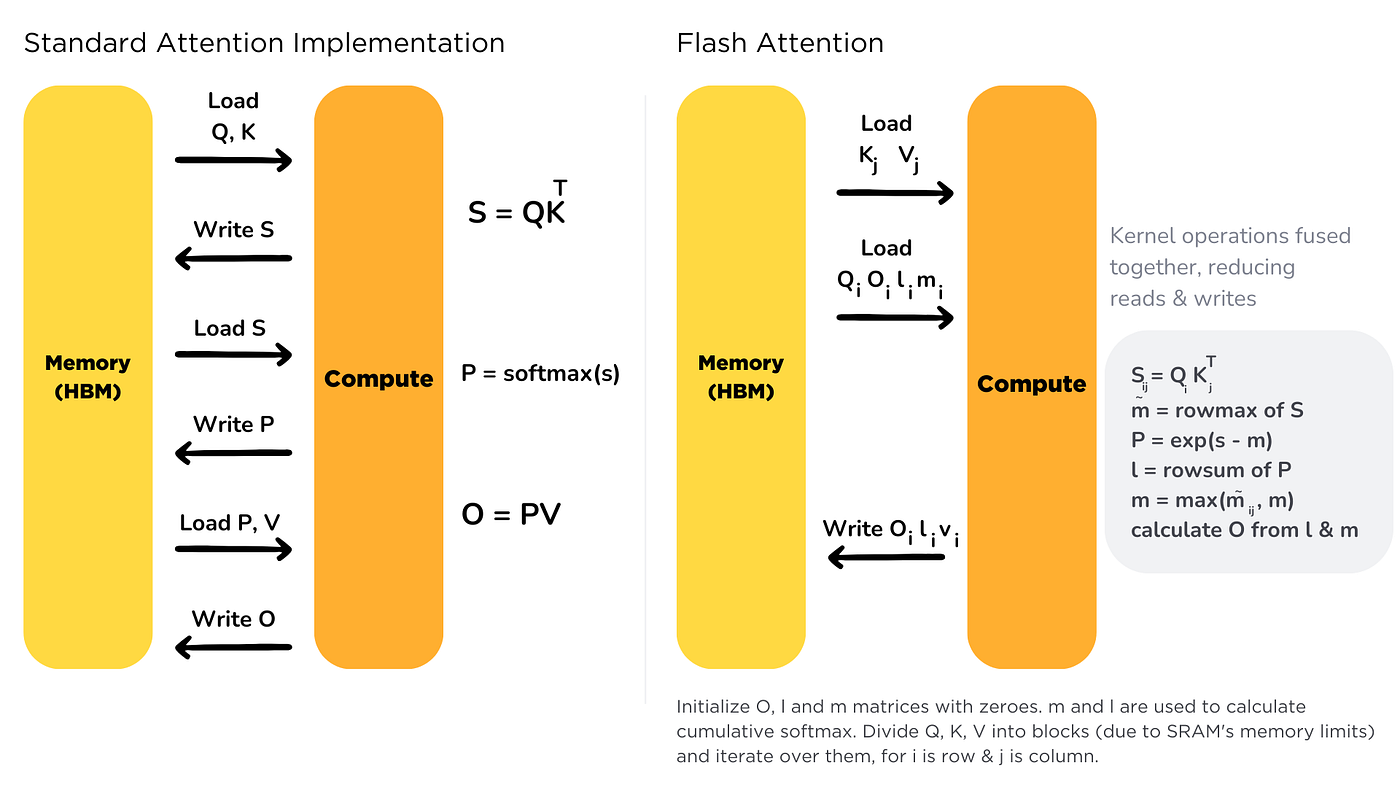

## Why Flash Attention?
Standard attention writes a full `N×N` score matrix to **HBM** (slow GPU memory). Flash Attention tiles Q/K/V into blocks that fit in fast on-chip **SRAM**, fuses all ops into one kernel, and **never materialises the N×N matrix**.

- Memory: `O(N)` vs `O(N²)` for naive
- Speed: ~2–4× faster on A100/H100 with fp16/bf16

---

## The Online Softmax Trick
Instead of computing softmax over the full row at once, it maintains running stats per tile:
```
m_new = max(m_old, rowmax(S_tile))          ← running max
ℓ_new = e^(m_old−m_new) * ℓ_old + rowsum(e^(S_tile−m_new))   ← running sum
O     = e^(m_old−m_new) * O + e^(S_tile−m_new) * V_tile        ← running output
```
After all tiles: `O /= ℓ` → **exactly equals** standard softmax attention.

---

## Structure: same as vanilla MHA, one key difference

The class is identical to standard MHA except **Step 3** replaces the manual score → mask → softmax → PV sequence with a single call:

```python
context_vec = F.scaled_dot_product_attention(
    query, key, value,
    attn_mask=None,
    dropout_p=self.dropout_rate if self.training else 0.0,
    is_causal=True,   # ← handles causal mask inside the kernel
)
```

**What this one call does internally:**
1. `S = Q @ Kᵀ / √head_dim`
2. Apply causal mask (upper triangle = `−∞`)
3. `P = softmax(S)` — tile-wise with online trick
4. Dropout on P (training only)
5. `O = P @ V`

---

## No mask buffer
Because `is_causal=True` generates the mask **inside the fused kernel**, there's no `register_buffer` for a causal mask — unlike vanilla MHA.

---

## Shape flow (same as vanilla MHA)
```
x          [B, N, d_in]
Q, K, V    [B, N, d_out]       ← after projections
Q, K, V    [B, H, N, head_dim] ← after .view + .transpose
ctx        [B, H, N, head_dim] ← SDPA output
ctx        [B, N, d_out]       ← after .transpose + .view
output     [B, N, d_out]       ← after out_proj
```

---

## Hardware note
- **Ampere/Ada/Hopper + fp16/bf16** → dispatches to Flash Attention CUDA kernel
- **CPU or older GPUs** → falls back to standard math (correct, just slower)

In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                     FLASH ATTENTION — QUICK REFERENCE                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  WHY: Standard attention writes a full N×N score matrix to HBM (slow GPU     ║
║  memory). For N=1024, H=8 that's ~64 MB per forward pass — pure bandwidth    ║
║  waste. Flash Attention tiles Q/K/V into blocks that fit in on-chip SRAM,    ║
║  fuses the dot-product → scale → mask → softmax → PV into a single kernel,   ║
║  and NEVER materialises the N×N matrix.                                      ║
║                                                                              ║
║  CORE TRICK — Online softmax:                                                ║
║    Instead of softmax(full row), maintain running stats per row:             ║
║      m_new = max(m_old, rowmax(S_tile))                                      ║
║      ℓ_new = e^(m_old - m_new) * ℓ_old + rowsum(e^(S_tile - m_new))          ║
║      O     ← e^(m_old - m_new) * O + e^(S_tile - m_new) * V_tile             ║
║    After all tiles: O /= ℓ  →  exactly equals standard softmax attention.    ║
║                                                                              ║
║  MEMORY: O(N)  vs  O(N²) for naive.                                          ║
║  SPEED:  ~2-4× faster on A100/H100 with fp16/bf16 (bandwidth bound).         ║
║  PYTORCH: F.scaled_dot_product_attention() dispatches to Flash automatically ║
║           on supported GPUs when no custom attn_mask is given.               ║
╚══════════════════════════════════════════════════════════════════════════════╝

Tensor shapes at each step (B=batch, N=seq_len, H=heads, d=head_dim):
  x          : [B, N, d_in]
  Q,K,V      : [B, N, d_out]          ← after W_q/W_k/W_v projections
  Q,K,V      : [B, H, N, d]           ← after .view + .transpose(1,2)
  context_vec: [B, H, N, d]           ← SDPA output, same shape
  context_vec: [B, N, H*d] = [B,N,d]  ← after .transpose + .view (heads merged)
  output     : [B, N, d_out]          ← after out_proj
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttentionFast(nn.Module):
    """
    Multi-head causal self-attention using Flash Attention via
    F.scaled_dot_product_attention (SDPA).

    Flash Attention memory layout recap:
      ┌─────────────┐   tiles    ┌──────────────────┐   one write
      │  HBM: Q,K,V │ ─────────► │  SRAM: fused ops │ ──────────► HBM: O
      └─────────────┘            │  QKᵀ · scale      │
        (slow, big)              │  + causal mask    │  (never writes N×N!)
                                 │  + softmax        │
                                 │  + PV             │
                                 └──────────────────┘
                                     (fast, tiny)
    """

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        # Each head gets an independent slice of the embedding dimension.
        # head_dim = d_out / num_heads  e.g. 256 / 8 = 32
        self.head_dim = d_out // num_heads

        # Three independent linear projections — no shared weights between Q, K, V.
        # Each maps [B, N, d_in] → [B, N, d_out].
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Final projection mixes information across all heads:
        # [B, N, d_out] → [B, N, d_out]
        self.out_proj = nn.Linear(d_out, d_out)

        self.dropout_rate = dropout

        # ── NOTE: no causal mask buffer here ──────────────────────────────────
        # With naive attention you'd register_buffer a (context_length, context_length)
        # upper-triangular bool mask and apply it manually.
        # SDPA with is_causal=True generates and applies the mask *inside the
        # fused kernel* on the GPU — no Python-level allocation, no HBM write.
        # ─────────────────────────────────────────────────────────────────────

    def forward(self, x):
        """
        Forward pass diagram:
          x [B,N,d_in]
            │
            ├─ W_query ──► Q [B,N,d_out]
            ├─ W_key   ──► K [B,N,d_out]   (1) linear projection
            └─ W_value ──► V [B,N,d_out]
                               │
                    .view + .transpose
                               │
                    Q,K,V [B, H, N, head_dim]     (2) split into H heads
                               │
                    ╔══════════╧═══════════╗
                    ║   Flash Attention    ║
                    ║  (fused CUDA kernel) ║      (3) SDPA
                    ║  tile Q, tile K/V    ║
                    ║  online softmax      ║
                    ║  is_causal mask      ║
                    ╚══════════╤═══════════╝
                               │
                    ctx [B, H, N, head_dim]
                               │
                    .transpose + .view
                               │
                    ctx [B, N, d_out]             (4) merge heads
                               │
                    out_proj
                               │
                    output [B, N, d_out]
        """
        b, num_tokens, d_in = x.shape

        # ── Step 1: Project input to Q, K, V ──────────────────────────────────
        # Shape after each: [B, N, d_out]  e.g. [2, 1024, 256]
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # ── Step 2: Reshape for multi-head — split d_out into H × head_dim ────
        # .view splits the last dim: [B, N, d_out] → [B, N, H, head_dim]
        # .transpose(1,2) swaps N and H dims: → [B, H, N, head_dim]
        # This lets SDPA treat each head independently as a separate batch dim.
        #   e.g. [2, 1024, 256] → [2, 1024, 8, 32] → [2, 8, 1024, 32]
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys   .view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values .view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # ── Step 3: Flash Attention via F.scaled_dot_product_attention ─────────
        #
        # What this single call does (all inside one fused GPU kernel):
        #   a. S = Q @ Kᵀ / √head_dim           ← scaled dot product
        #   b. Apply causal mask (upper triangle = -inf)  ← is_causal=True
        #   c. P = softmax(S, dim=-1)             ← tile-wise, with online trick
        #   d. if training: dropout on P
        #   e. O = P @ V                          ← weighted sum of values
        #
        # Key arguments:
        #   attn_mask=None   — let is_causal handle masking (more efficient)
        #   is_causal=True   — enables the causal upper-triangular mask;
        #                      SDPA uses this to select the Flash Attention path
        #   dropout_p        — only applied during training (guarded by self.training)
        #
        # On Ampere/Ada/Hopper GPUs with fp16/bf16 this dispatches to the
        # triton/cuDNN Flash Attention kernel. On CPU or older GPUs it falls
        # back to standard math — still correct, just slower.
        context_vec = F.scaled_dot_product_attention(
            query     = queries,
            key       = keys,
            value     = values,
            attn_mask = None,
            dropout_p = self.dropout_rate if self.training else 0.0,
            is_causal = True,
        )
        # context_vec shape: [B, H, N, head_dim]  e.g. [2, 8, 1024, 32]

        # ── Step 4: Merge heads and project output ─────────────────────────────
        # .transpose(1,2): [B, H, N, head_dim] → [B, N, H, head_dim]
        # .contiguous():   make memory layout contiguous before .view
        # .view(...):      [B, N, H, head_dim] → [B, N, d_out]  (H * head_dim = d_out)
        context_vec = context_vec.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)

        # Final linear projection mixes information across all heads.
        context_vec = self.out_proj(context_vec)
        # output shape: [B, N, d_out]  e.g. [2, 1024, 256]

        return context_vec


# ── Test ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    torch.manual_seed(123)

    # Simulating a typical GPT-style config
    batch_size     = 2
    context_length = 1024
    embed_dim      = 256
    num_heads      = 8
    # → head_dim = 256 / 8 = 32

    mock_inputs = torch.randn(batch_size, context_length, embed_dim)

    # Flash Attention speed notes:
    #  • Requires Ampere (A100, RTX 3090) or newer to trigger the fast CUDA path
    #  • Use .half() or .to(torch.bfloat16) for maximum speedup
    #  • On CPU or older GPUs SDPA falls back to standard scaled dot product
    #    (correct output, no Flash speedup)
    mha_fast = MultiHeadAttentionFast(
        d_in           = embed_dim,
        d_out          = embed_dim,
        context_length = context_length,
        dropout        = 0.0,
        num_heads      = num_heads,
    )

    output = mha_fast(mock_inputs)
    print("Input shape  :", mock_inputs.shape)   # [2, 1024, 256]
    print("Output shape :", output.shape)         # [2, 1024, 256]
    print("Fast MHA executed successfully.")

    # To check whether SDPA actually used Flash Attention on your hardware:
    # with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=False):
    #     output = mha_fast(mock_inputs.cuda().half())
    # If it raises RuntimeError, Flash Attention is not available on this GPU.

Input shape  : torch.Size([2, 1024, 256])
Output shape : torch.Size([2, 1024, 256])
Fast MHA executed successfully.
